In [9]:
print("hello world")

hello world


In [10]:
#importing tools and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error 
from sklearn.metrics import mean_squared_error

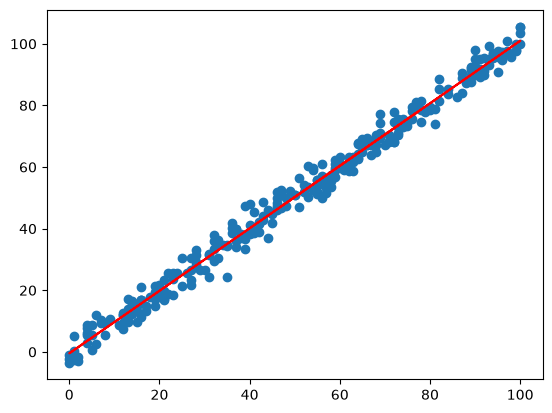

In [11]:
#graphs
df = pd.read_csv("test.csv")
x = df[["x"]]
y = df[["y"]]


slope, intercept = np.polyfit(df["x"], df["y"], 1)

# 2. Calculate the predicted y values for the line
y_pred = slope * x + intercept

plt.scatter(x, y)
plt.plot(x, y_pred, color = "red")


In [12]:
df

,x,y
0,77,79.775152
1,21,23.177279
2,22,25.609262
3,20,17.857388
4,36,41.849864
...,...,...
295,71,68.545888
296,46,47.334876
297,55,54.090637
298,62,63.297171


In [13]:
#training
X_train, X_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
lm = LinearRegression()
lm.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[1.01]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['x']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-0.36]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


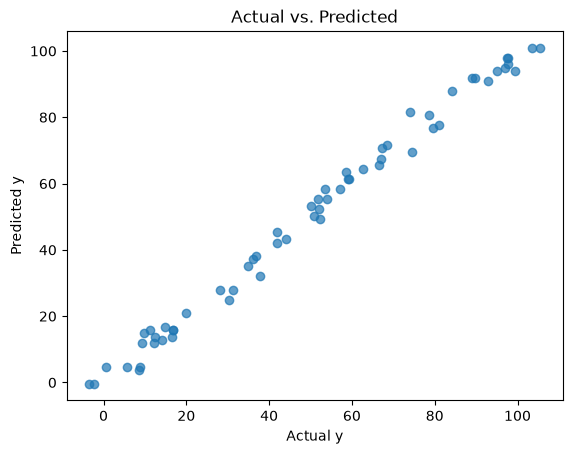

In [14]:
# Option A: Actual vs Predicted Scatter
pred = lm.predict(X_test)
plt.scatter(y_test, pred, alpha=0.7)
plt.xlabel("Actual y")
plt.ylabel("Predicted y")
plt.title("Actual vs. Predicted")
plt.show()

2.5178022909112228 9.259410978631752
(60, 1)


(array([2., 1., 0., 2., 0., 1., 0., 1., 0., 0., 2., 0., 3., 0., 1., 0., 2.,
        1., 0., 2., 1., 4., 1., 0., 2., 0., 4., 2., 0., 1., 2., 3., 0., 1.,
        4., 2., 1., 1., 1., 2., 2., 1., 1., 1., 0., 1., 0., 3., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 1.]),
 array([-5.73185903, -5.50632252, -5.280786  , -5.05524949, -4.82971298,
        -4.60417647, -4.37863996, -4.15310344, -3.92756693, -3.70203042,
        -3.47649391, -3.2509574 , -3.02542088, -2.79988437, -2.57434786,
        -2.34881135, -2.12327484, -1.89773832, -1.67220181, -1.4466653 ,
        -1.22112879, -0.99559228, -0.77005576, -0.54451925, -0.31898274,
        -0.09344623,  0.13209028,  0.3576268 ,  0.58316331,  0.80869982,
         1.03423633,  1.25977284,  1.48530936,  1.71084587,  1.93638238,
         2.16191889,  2.3874554 ,  2.61299191,  2.83852843,  3.06406494,
         3.28960145,  3.51513796,  3.74067447,  3.96621099,  4.1917475 ,
         4.41728401,  4.64282052,  4.86835703,  5.09389355,  5.319430

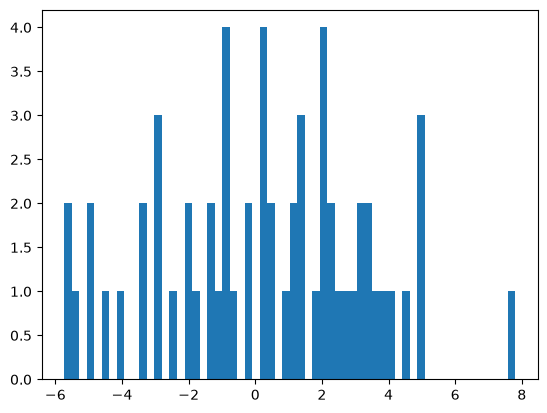

In [15]:
print(mean_absolute_error(y_test, pred), mean_squared_error(y_test, pred))
print(pred.shape)
res = pred - y_test
plt.hist(res, 60)